<a href="https://colab.research.google.com/github/sourabhverma1302/AI-ML-Journey/blob/main/Titanic_Neural.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

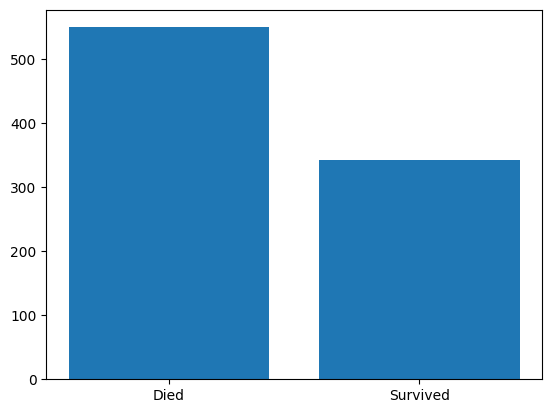

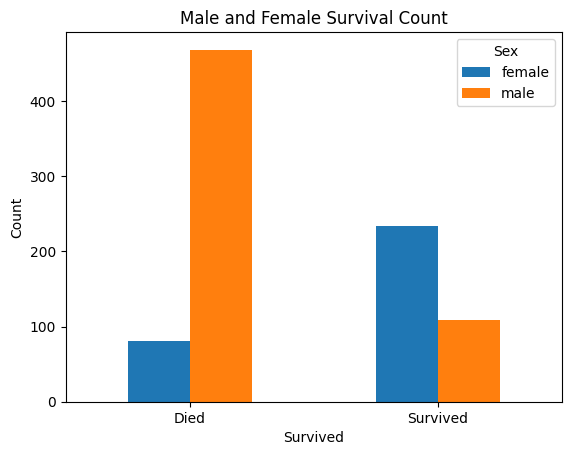

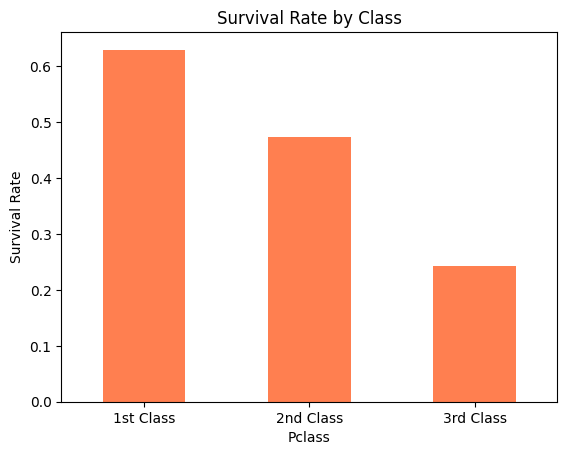

   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked  Ticket_Group
0         0       3    0  22.0      1      0   7.2500         0             1
1         1       1    1  38.0      1      0  71.2833         1             1
2         1       3    1  26.0      0      0   7.9250         0             1
3         1       1    1  35.0      1      0  53.1000         0             2
4         0       3    0  35.0      0      0   8.0500         0             1
Epoch:  0 loss:0.6570
Epoch: 50 loss:0.5430
Epoch:100 loss:0.4642
Epoch:150 loss:0.4485
Epoch:200 loss:0.4264
Epoch:250 loss:0.4289
Epoch:300 loss:0.4206
Epoch:350 loss:0.4310
Epoch:400 loss:0.4333
Epoch:450 loss:0.4294

Final Test Accuracy: 81.01%


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

data=pd.read_csv('./train.csv')

df=pd.DataFrame(data)

survived_died=df['Survived'].value_counts()

plt.bar(
    ['Died','Survived'],survived_died
)
plt.show()
df['Age']=df['Age'].fillna(df['Age'].mean())


ax = df.groupby('Survived')['Sex'].value_counts().unstack().plot(kind='bar')

# change x-axis labels
ax.set_xticklabels(['Died', 'Survived'], rotation=0)

plt.ylabel("Count")
plt.title("Male and Female Survival Count")

plt.show()

ticket_counts = df['Ticket'].value_counts()

df['Ticket_Group'] = df['Ticket'].map(ticket_counts)

# Survival by passenger class
df.groupby("Pclass")["Survived"].mean().plot(kind="bar", color="coral")
plt.title("Survival Rate by Class")
plt.ylabel("Survival Rate")
plt.xticks([0,1,2], ["1st Class","2nd Class","3rd Class"], rotation=0)
plt.show()

df["Sex"]=df["Sex"].map({"male":0,"female":1})

df["Embarked"]=df["Embarked"].fillna(df["Embarked"].mode()[0])

df["Embarked"]=df["Embarked"].map({"S":0,"C":1,"Q":2}).astype(int)

# Age distribution of survivors vs died
# df[df["Survived"]==1]["Age"].hist(alpha=0.5, label="Survived", bins=20)
# df[df["Survived"]==0]["Age"].hist(alpha=0.5, label="Died", bins=20)
# plt.legend()
# plt.title("Age Distribution — Survived vs Died")
# plt.show()

df=df.drop(["Name","PassengerId","Ticket","Cabin"],axis=1)

print(df.head())

X=df.drop(["Survived"],axis=1)
y=df["Survived"]

scaler=StandardScaler()
X=scaler.fit_transform(X)

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


X_train=torch.FloatTensor(X_train)
X_test=torch.FloatTensor(X_test)
y_train=torch.LongTensor(y_train.values)
y_test=torch.LongTensor(y_test.values)


model=nn.Sequential(
    nn.Linear(8,32),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(32,16),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(16,2)
)

optimizer=torch.optim.Adam(model.parameters(),lr=0.001,weight_decay=0.01)
criterion=nn.CrossEntropyLoss()

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)


for epoch in range(500):
  optimizer.zero_grad()
  output=model(X_train)
  loss=criterion(output,y_train)
  loss.backward()
  optimizer.step()
  scheduler.step()                 # Update learning rate

  if epoch % 50 == 0:
    print(f"Epoch:{epoch:3d} loss:{loss.item():.4f}")


with torch.no_grad():
        output = model(X_test)
        prediction=output.argmax(dim=1)


        test_accuracy = (prediction == y_test).float().mean()
        print(f'\nFinal Test Accuracy: {test_accuracy * 100:.2f}%')


